In [1]:
import os
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import shuffle
from tqdm import tqdm

In [2]:
np.random.seed(42)
torch.manual_seed(42)

# Study population

#### MIMIC: create training, validation, and testing cohorts

In [43]:
data_dir = '/Users/calummaclellan/Documents/PhD/data/mimic-cxr/foundation-model-embeddings/'

input_csv = 'MIMIC.sample.test.csv'

output_suffix = 'resample'

sample_size_factor = 4

#### Preprocessing

In [44]:
df = pd.read_csv(data_dir + input_csv).drop(columns=['Unnamed: 0', 'Unnamed: 0.1', 'Unnamed: 0.2', 'Unnamed: 0.3'])
print(df.shape)
# df = pd.read_csv(data_dir + input_csv)
# df.drop(columns=df.columns.str.contains('Unnamed'), inplace=True)

def bin_age(age):
    if age <= 20:
        return 0
    if age <= 30:
        return 1
    if age <= 40:
        return 2
    if age <= 50:
        return 3
    if age <= 60:
        return 4
    if age <= 70:
        return 5
    if age <= 80:
        return 6
    return 7

df["age_bin"] = df["age"].apply(bin_age)

(93324, 36)


#### Resample df to have equal proportion of Asian, Black, White

In [45]:
n_samples = len(df) * sample_size_factor
w_race = (1 / df.value_counts("race_label", normalize=True)).to_dict()
print(w_race)

ids = list(torch.utils.data.WeightedRandomSampler(df["race_label"].apply(lambda x: w_race[x]).values, n_samples, replacement=True))
df_balanced_race = df.iloc[ids]
df_balanced_race.value_counts("race_label", normalize=True)
print(df_balanced_race.shape)

{'0': 1.6938434732103964, 'Other': 4.242771412984179, '2': 6.932402317634824, '1': 33.69097472924188}
(373296, 37)


#### Within each (race)-subgroup  ensure equal prevalence. Within each (race, disease)-subsubgroup ensure equal age distribution.

In [46]:
subgroups = [df_balanced_race.loc[df_balanced_race["race_label"] == i] for i in df_balanced_race.race_label.unique()]
overall_proportion_disease = df.value_counts("disease_label", normalize=True)
disease_labels = df.disease_label.unique()
overall_proportion_age_per_disease_label = [df.loc[df.disease_label == d].value_counts("age_bin", normalize=True) for d in disease_labels]

for i, subgroup in enumerate(subgroups):
        
        # 1. Ensure constant disease prevalence in each subgroup
        n_samples = len(subgroup)
        observed_proportion = subgroup.value_counts("disease_label", normalize=True)
        w = (overall_proportion_disease / observed_proportion).to_dict()
        ids = list(torch.utils.data.WeightedRandomSampler(subgroup["disease_label"].apply(lambda x: w[x]).values, n_samples, replacement=True))
        subgroups[i] = subgroup.iloc[ids]

        # 2. Further ensure constant age repartition across groups
        subsubgroups = [subgroups[i].loc[subgroups[i].disease_label == d] for d in disease_labels]
        for j, subsubgroup in enumerate(subsubgroups): 
                n_samples = len(subsubgroup)
                observed_proportion = subsubgroup.value_counts("age_bin", normalize=True)
                w = (overall_proportion_age_per_disease_label[j] / observed_proportion).to_dict()
                ids = list(torch.utils.data.WeightedRandomSampler(subsubgroup["age_bin"].apply(lambda x: w[x]).values, n_samples, replacement=True))
                subsubgroups[j] = subsubgroup.iloc[ids]

        subgroups[i] = pd.concat(subsubgroups)
        
balanced_df = pd.concat(subgroups)

#### Check balanced dataset

In [47]:
balanced_df.groupby(["race"]).size()

race
Asian    93201
Black    92983
Other    93385
White    93727
dtype: int64

In [48]:
balanced_df.groupby(["race", "disease_label"]).size()

race   disease_label
Asian  0                31176
       1                22407
       2                39618
Black  0                31061
       1                22140
       2                39782
Other  0                31314
       1                22101
       2                39970
White  0                31208
       1                22322
       2                40197
dtype: int64

In [49]:
balanced_df.groupby(["race", "disease_label", "age_bin"]).size()

race   disease_label  age_bin
Asian  0              0           654
                      1          3115
                      2          3082
                      3          4720
                      4          6242
                                 ... 
White  2              3          4288
                      4          7963
                      5          8987
                      6          7275
                      7          7608
Length: 96, dtype: int64

#### Save balanced dataset

In [50]:
balanced_df.to_csv(data_dir + input_csv.replace('sample',output_suffix))

## Plots

In [51]:
df_cxr = pd.read_csv(data_dir + input_csv.replace('sample',output_suffix))

/var/folders/rz/h7cm1h2j06vbbj_t9vl0ktk80000gn/T/ipykernel_27406/1696575834.py:1: DtypeWarning: Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.
  df_cxr = pd.read_csv(data_dir + input_csv.replace('sample',output_suffix))


In [52]:
df_cxr.loc[df_cxr['disease'] == 'Pleural Effusion', 'disease'] = 'Pleur. Eff.'
df_cxr.loc[df_cxr['disease'] == 'No Finding', 'disease'] = 'No Find.'

df_cxr.loc[df_cxr['sex'] == 'M', 'sex'] = 'Male'
df_cxr.loc[df_cxr['sex'] == 'F', 'sex'] = 'Female'

In [53]:
df_subgroup = df_cxr[df_cxr['race_label']==0]
prev_0 = len(df_subgroup[df_subgroup['disease_label']==0]) / len(df_subgroup)
prev_1 = len(df_subgroup[df_subgroup['disease_label']==1]) / len(df_subgroup)
prev_2 = len(df_subgroup[df_subgroup['disease_label']==2]) / len(df_subgroup)
print('')
print('Prevalence - White')
print('No-finding:\t\t{:.2f}'.format(prev_0))
print('Pleural effusion:\t{:.2f}'.format(prev_1))
print('Other:\t\t\t{:.2f}'.format(prev_2))

df_subgroup = df_cxr[df_cxr['race_label']==1]
prev_0 = len(df_subgroup[df_subgroup['disease_label']==0]) / len(df_subgroup)
prev_1 = len(df_subgroup[df_subgroup['disease_label']==1]) / len(df_subgroup)
prev_2 = len(df_subgroup[df_subgroup['disease_label']==2]) / len(df_subgroup)
print('')
print('Prevalence - Asian')
print('No-finding:\t\t{:.2f}'.format(prev_0))
print('Pleural effusion:\t{:.2f}'.format(prev_1))
print('Other:\t\t\t{:.2f}'.format(prev_2))

df_subgroup = df_cxr[df_cxr['race_label']==2]
prev_0 = len(df_subgroup[df_subgroup['disease_label']==0]) / len(df_subgroup)
prev_1 = len(df_subgroup[df_subgroup['disease_label']==1]) / len(df_subgroup)
prev_2 = len(df_subgroup[df_subgroup['disease_label']==2]) / len(df_subgroup)
print('')
print('Prevalence - Black')
print('No-finding:\t\t{:.2f}'.format(prev_0))
print('Pleural effusion:\t{:.2f}'.format(prev_1))
print('Other:\t\t\t{:.2f}'.format(prev_2))

df_subgroup = df_cxr[df_cxr['race_label']=='Other']
prev_0 = len(df_subgroup[df_subgroup['disease_label']==0]) / len(df_subgroup)
prev_1 = len(df_subgroup[df_subgroup['disease_label']==1]) / len(df_subgroup)
prev_2 = len(df_subgroup[df_subgroup['disease_label']==2]) / len(df_subgroup)
print('')
print('Prevalence - Other')
print('No-finding:\t\t{:.2f}'.format(prev_0))
print('Pleural effusion:\t{:.2f}'.format(prev_1))
print('Other:\t\t\t{:.2f}'.format(prev_2))



Prevalence - White
No-finding:		0.34
Pleural effusion:	0.24
Other:			0.42

Prevalence - Asian
No-finding:		0.33
Pleural effusion:	0.24
Other:			0.43

Prevalence - Black
No-finding:		0.33
Pleural effusion:	0.24
Other:			0.43

Prevalence - Other
No-finding:		0.34
Pleural effusion:	0.24
Other:			0.43


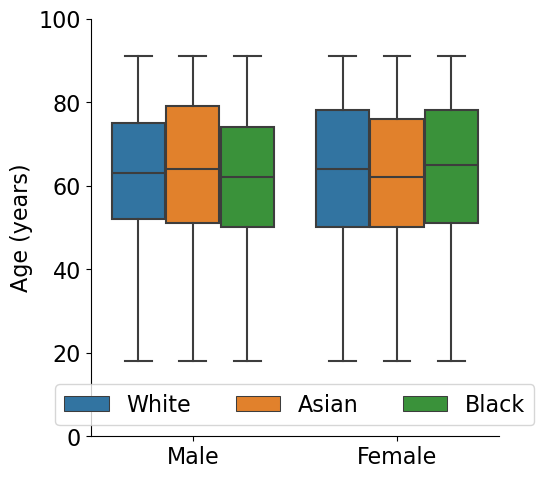

In [58]:
fontsize = 16
plt.rc('xtick', labelsize=fontsize) 
plt.rc('ytick', labelsize=fontsize)

fig = sns.catplot(x='sex', y='age', hue='race', order=['Male', 'Female'], hue_order=['White', 'Asian', 'Black'], kind="box", data=df_cxr)
fig._legend.remove()
plt.xlabel('', fontsize=fontsize)
plt.ylabel('Age (years)', fontsize=fontsize)
plt.ylim([0, 100])
plt.legend(fontsize=fontsize, loc='lower center', ncol=3)
plt.show()
fig.savefig('../notebooks/MIMIC-data-info/' + "MIMIC-CXR-resample-age-sex-race.png", bbox_inches='tight', dpi=300)

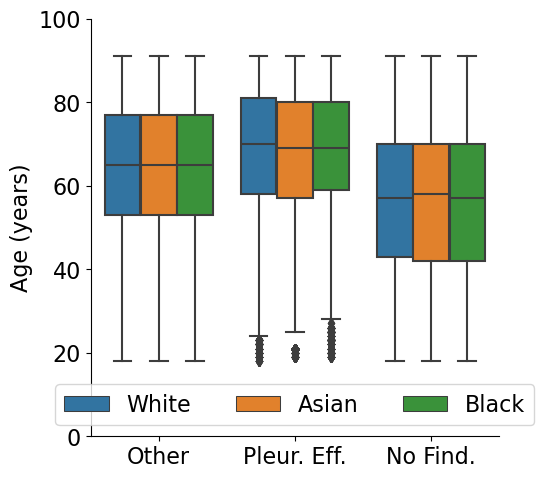

In [59]:
fig = sns.catplot(x='disease', y='age', hue='race', order=['Other', 'Pleur. Eff.', 'No Find.'], hue_order=['White', 'Asian', 'Black'], kind="box", data=df_cxr)
fig._legend.remove()
plt.xlabel('', fontsize=fontsize)
plt.ylabel('Age (years)', fontsize=fontsize)
plt.ylim([0, 100])
plt.legend(fontsize=fontsize, loc='lower center', ncol=3)
plt.show()
fig.savefig("MIMIC-CXR-resample-age-pathology-race.png", bbox_inches='tight', dpi=300)

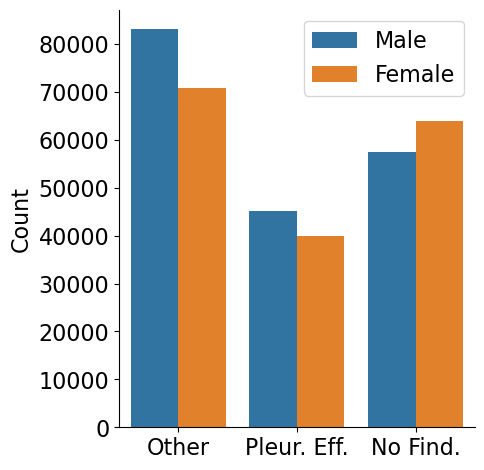

In [60]:
fig = sns.catplot(x='disease', hue='sex', order=['Other', 'Pleur. Eff.', 'No Find.'], hue_order=['Male', 'Female'], data=df_cxr, kind='count')
fig._legend.remove()
plt.xlabel('', fontsize=fontsize)
plt.ylabel('Count', fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.show()
fig.savefig("MIMIC-CXR-resample-sex-pathology.png", bbox_inches='tight', dpi=300)

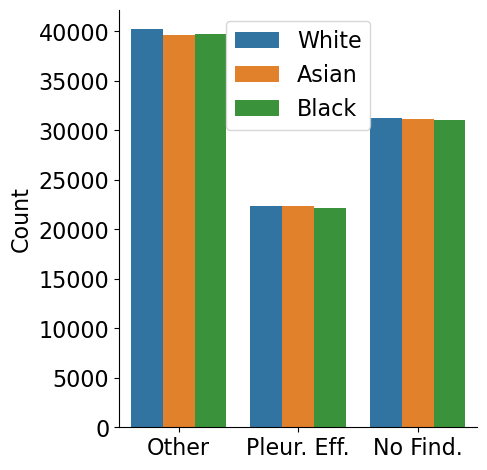

In [61]:
fig = sns.catplot(x='disease', hue='race', order=['Other', 'Pleur. Eff.', 'No Find.'], hue_order=['White', 'Asian', 'Black'], data=df_cxr, kind='count')
fig._legend.remove()
plt.xlabel('', fontsize=fontsize)
plt.ylabel('Count', fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.show()
fig.savefig("MIMIC-CXR-resample-race-pathology.png", bbox_inches='tight', dpi=300)

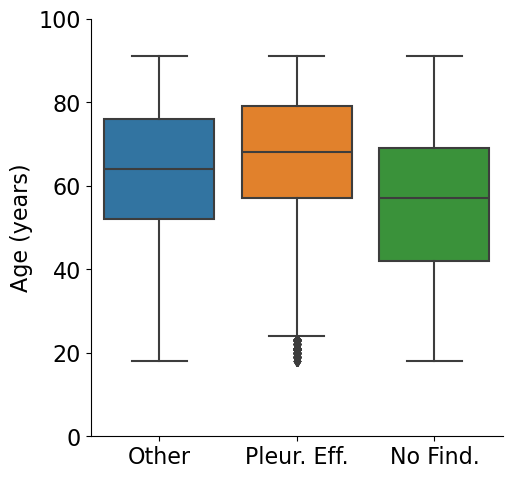

In [62]:
fig = sns.catplot(x='disease', y='age', order=['Other', 'Pleur. Eff.', 'No Find.'], kind="box", data=df_cxr)
plt.xlabel('', fontsize=fontsize)
plt.ylabel('Age (years)', fontsize=fontsize)
plt.ylim([0, 100])
plt.show()
fig.savefig("MIMIC-CXR-resample-age-pathology.png", bbox_inches='tight', dpi=300)

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


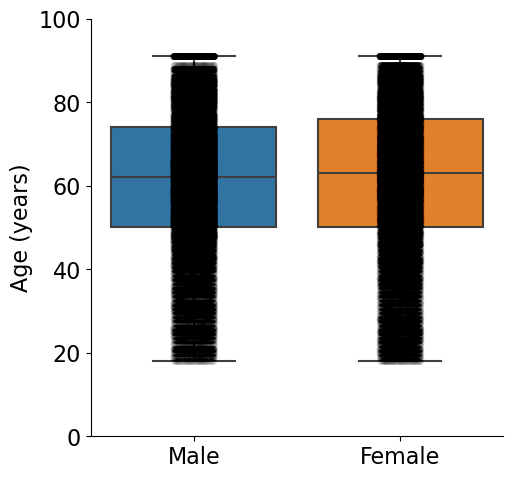

In [63]:
fig = sns.catplot(x='sex', y='age', order=['Male', 'Female'], kind="box", data=df_cxr)
sns.stripplot(x='sex', y='age', color='k', order=['Male', 'Female'], alpha=0.01, data=df_cxr, ax=fig.ax)
plt.xlabel('', fontsize=fontsize)
plt.ylabel('Age (years)', fontsize=fontsize)
plt.ylim([0, 100])
plt.show()
fig.savefig("MIMIC-CXR-resample-age-sex.png", bbox_inches='tight', dpi=300)

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


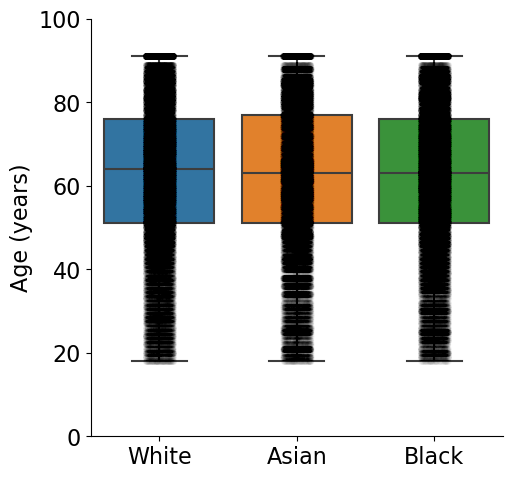

In [64]:
fig = sns.catplot(x='race', y='age', order=['White', 'Asian', 'Black'], kind="box", data=df_cxr)
sns.stripplot(x='race', y='age', color='k', order=['White', 'Asian', 'Black'], alpha=0.01, data=df_cxr, ax=fig.ax)
plt.xlabel('', fontsize=fontsize)
plt.ylabel('Age (years)', fontsize=fontsize)
plt.ylim([0, 100])
plt.show()
fig.savefig("MIMIC-CXR-resample-age-race.png", bbox_inches='tight', dpi=300)

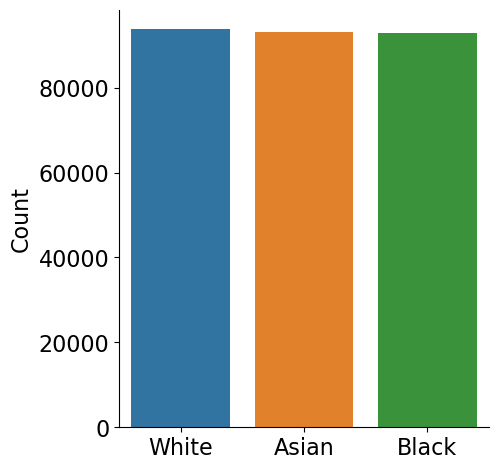

In [65]:
fig = sns.catplot(x='race', order=['White', 'Asian', 'Black'], data=df_cxr, kind='count')
plt.xlabel('', fontsize=fontsize)
plt.ylabel('Count', fontsize=fontsize)
plt.show()
fig.savefig("MIMIC-CXR-resample-race.png", bbox_inches='tight', dpi=300)

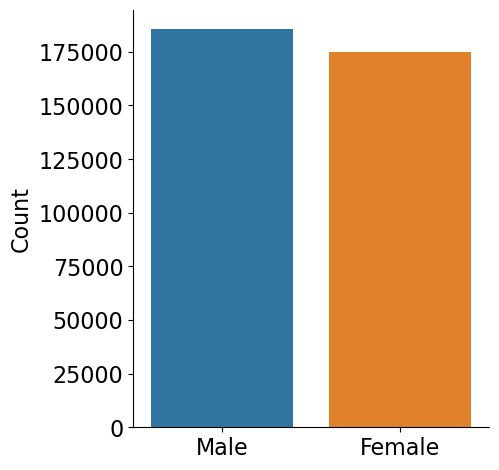

In [66]:
fig = sns.catplot(x='sex', order=['Male', 'Female'], data=df_cxr, kind='count')
plt.xlabel('', fontsize=fontsize)
plt.ylabel('Count', fontsize=fontsize)
plt.show()
fig.savefig("MIMIC-CXR-resample-sex.png", bbox_inches='tight', dpi=300)

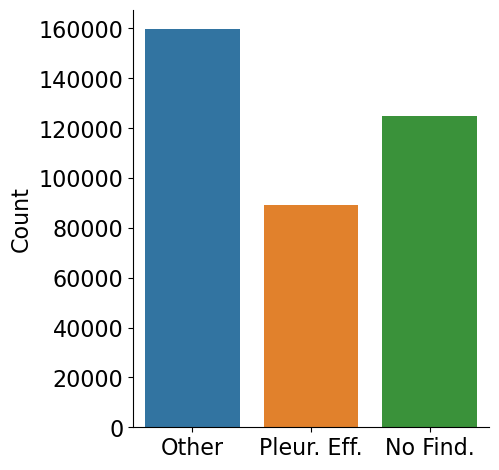

In [67]:
fig = sns.catplot(x='disease', order=['Other', 'Pleur. Eff.', 'No Find.'], data=df_cxr, kind='count')
plt.xlabel('', fontsize=fontsize)
plt.ylabel('Count', fontsize=fontsize)
plt.show()
fig.savefig("MIMIC-CXR-resample-pathology.png", bbox_inches='tight', dpi=300)

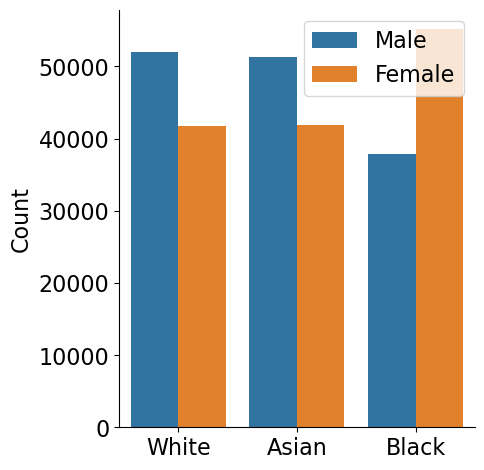

In [68]:
fig = sns.catplot(x='race', hue='sex', order=['White', 'Asian', 'Black'], hue_order=['Male', 'Female'], data=df_cxr, kind='count')
fig._legend.remove()
plt.xlabel('', fontsize=fontsize)
plt.ylabel('Count', fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.show()
fig.savefig("MIMIC-CXR-resample-sex-race.png", bbox_inches='tight', dpi=300)

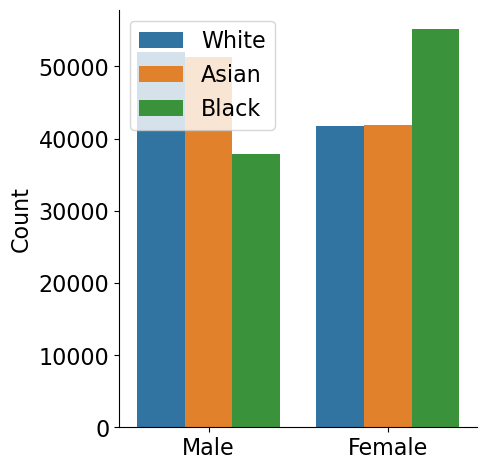

In [69]:
fig = sns.catplot(x='sex', hue='race', order=['Male', 'Female'], hue_order=['White', 'Asian', 'Black'], data=df_cxr, kind='count')
fig._legend.remove()
plt.xlabel('', fontsize=fontsize)
plt.ylabel('Count', fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.show()
fig.savefig("MIMIC-CXR-resample-race-sex.png", bbox_inches='tight', dpi=300)